In [2]:
from framework import (
    EpsilonGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [21]:
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

baseline_history = simulation.run()

Convergence detected after 69720 rounds.
Bidder Agent1 had converged to  0.30000000000000004
Bidder Agent2 had converged to  0.30000000000000004


In [22]:
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

history_01 = simulation.run()

Convergence detected after 71318 rounds.
Bidder Agent1 had converged to  0.2
Bidder Agent2 had converged to  0.2


In [23]:
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.9)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.9)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

history_09 = simulation.run()

Convergence detected after 74008 rounds.
Bidder Agent1 had converged to  0.2
Bidder Agent2 had converged to  0.2


In [11]:
baseline = pd.read_csv("Results_FPA/Initial results/FPA_auction_summary_results.csv")

In [5]:
FPA_2stochastic = []
FPA_1stochastic = []
for i in range(9):
    df2 = pd.read_csv(f"Results_FPA/Stochastic/FPA_stochastic_0_{i+1}_results.csv")
    df1 = pd.read_csv(f"Results_FPA/Stochastic/FPA_stochastic_0_{i+1}_asym_results.csv")
    FPA_2stochastic.append(df2)
    FPA_1stochastic.append(df1)

In [6]:
FPA_2stochastic[0].head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,0,75578,0.30,28.948864,0.30,29.158922
1,1,76283,0.20,30.715704,0.20,31.282080
2,2,73628,0.25,31.124464,0.25,29.803906
3,3,72428,0.20,31.202424,0.20,32.256210
4,4,70955,0.10,34.747572,0.10,33.272559


In [ ]:
baseline_mean = baseline["converged_bid_Agent1"].mean()
print(f"The mean bid converged to for symmetric basiline simulations is {baseline_mean}")

for i, df in enumerate(FPA_2stochastic):
    bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2"]
    df["max_bid_per_sim"] = df[bid_cols].max(axis=1)
    converged_bid_mean = df["max_bid_per_sim"].mean()
    print(f"s = 0.{i+1}: {converged_bid_mean}")

   

The mean bid converged to for symmetric basiline simulations is 0.22750000000000004
s = 0.1: 0.222
s = 0.2: 0.2045
s = 0.3: 0.20450000000000002
s = 0.4: 0.19149999999999998
s = 0.5: 0.18899999999999997
s = 0.6: 0.1805
s = 0.7: 0.16449999999999998
s = 0.8: 0.16999999999999996
s = 0.9: 0.163
The mean bid converged to when agents have stochastic shock s


In [17]:
baseline_mean = baseline["converged_bid_Agent1"].mean()
print(f"The mean bid converged to for symmetric basiline simulations is {baseline_mean}")

for i, df in enumerate(FPA_1stochastic):
    bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2"]
    df["max_bid_per_sim"] = df[bid_cols].max(axis=1)
    converged_bid_mean = df["max_bid_per_sim"].mean()
    print(f"s = 0.{i+1}: {converged_bid_mean}")

The mean bid converged to for symmetric basiline simulations is 0.22750000000000004
s = 0.1: 0.233
s = 0.2: 0.22
s = 0.3: 0.21000000000000005
s = 0.4: 0.21100000000000002
s = 0.5: 0.206
s = 0.6: 0.218
s = 0.7: 0.23300000000000004
s = 0.8: 0.265
s = 0.9: 0.41450000000000004


In [24]:
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

FPA_history_01 = simulation.run()

Convergence detected after 74183 rounds.
Bidder Agent1 had converged to  0.1
Bidder Agent2 had converged to  0.1


In [26]:
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)

simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

SPA_history_01 = simulation.run()

Agents have not converged after 1,000,000 rounds


In [28]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

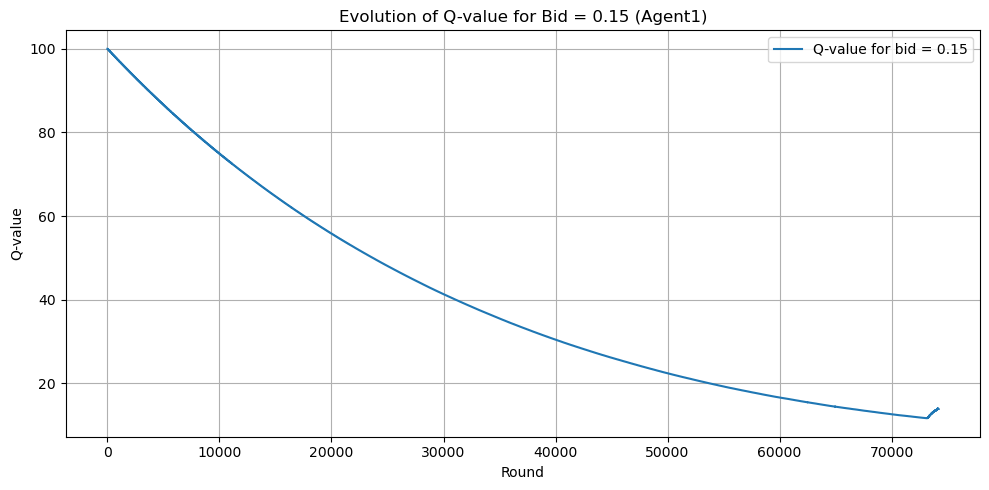

In [32]:
bidder_name = "Agent1"
bid_index = 1

q_trajectory = extract_q_trajectory(FPA_history_01, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.15")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.15 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

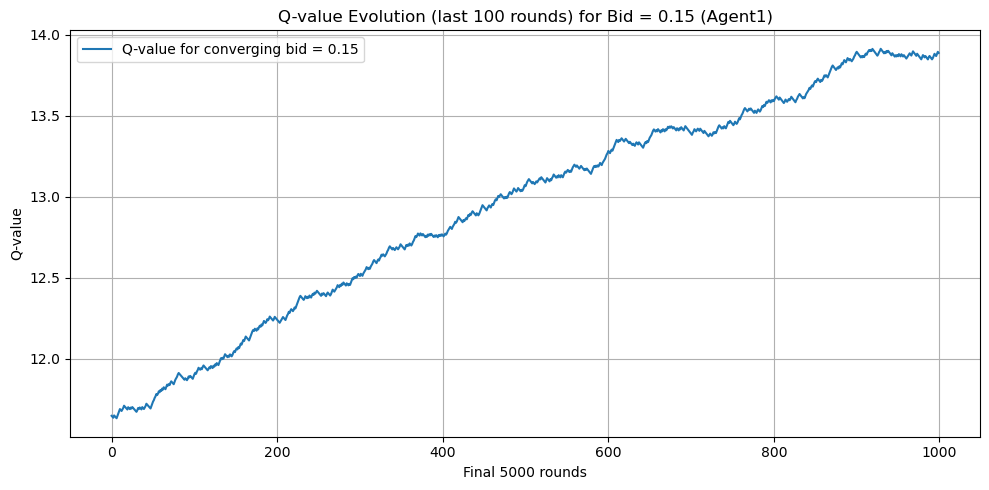

In [37]:
# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-1000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for converging bid = {0.15}")
plt.xlabel("Final 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 100 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
def plot_q_evolution(history, bidder_name, n_last=5000):
    # Only keep the last n_last periods
    hist_tail = history[-n_last:]

    # Define bid grid (matches your environment setup)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot the Q-value trajectory for each bid
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_tail, bidder_name, bid_idx)
        plt.plot(q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds (last {n_last} steps)")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

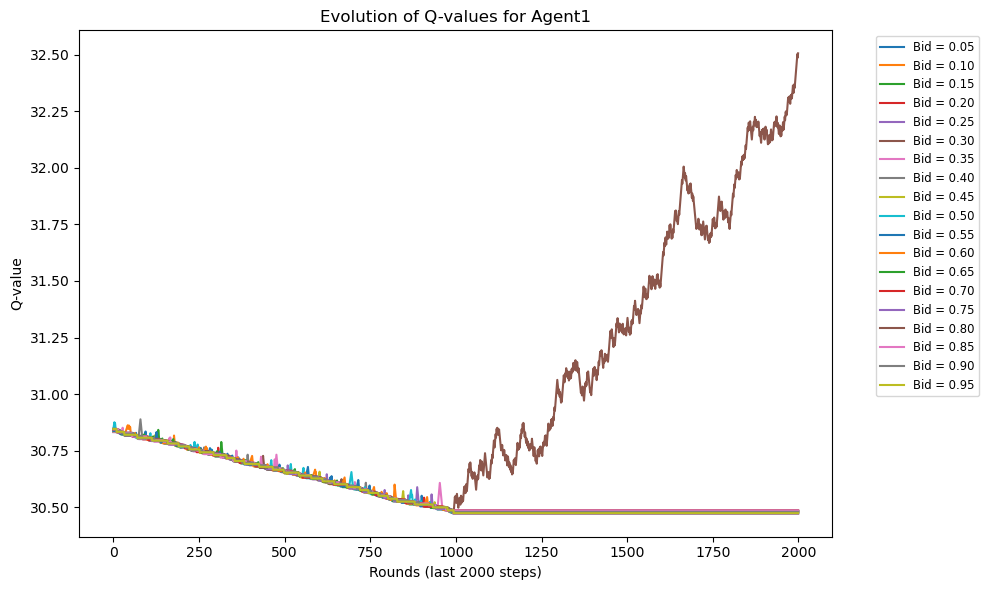

In [42]:
plot_q_evolution(baseline_history, "Agent1", n_last=2000)

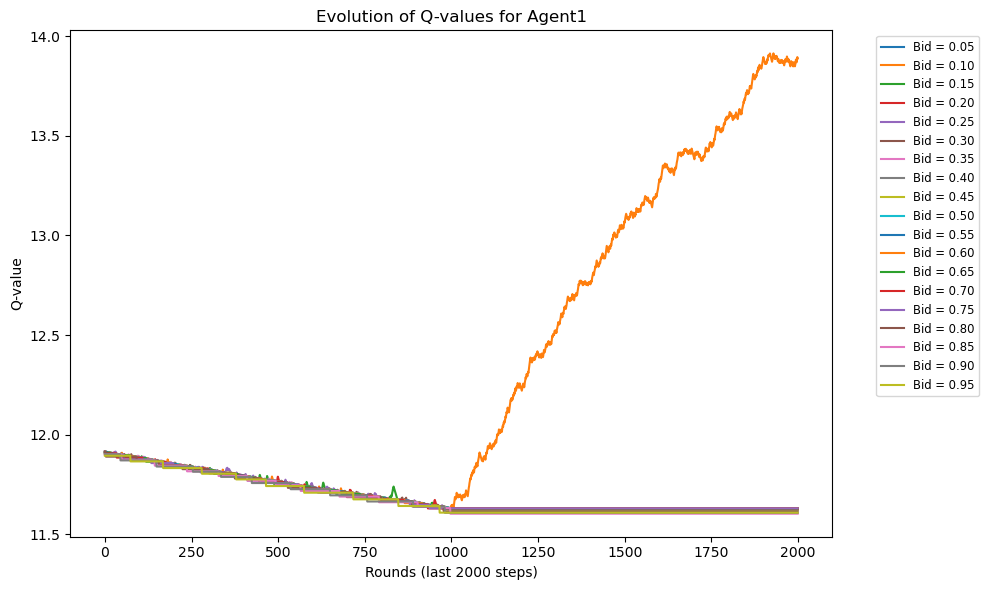

In [44]:
plot_q_evolution(FPA_history_01, "Agent1", n_last=2000)

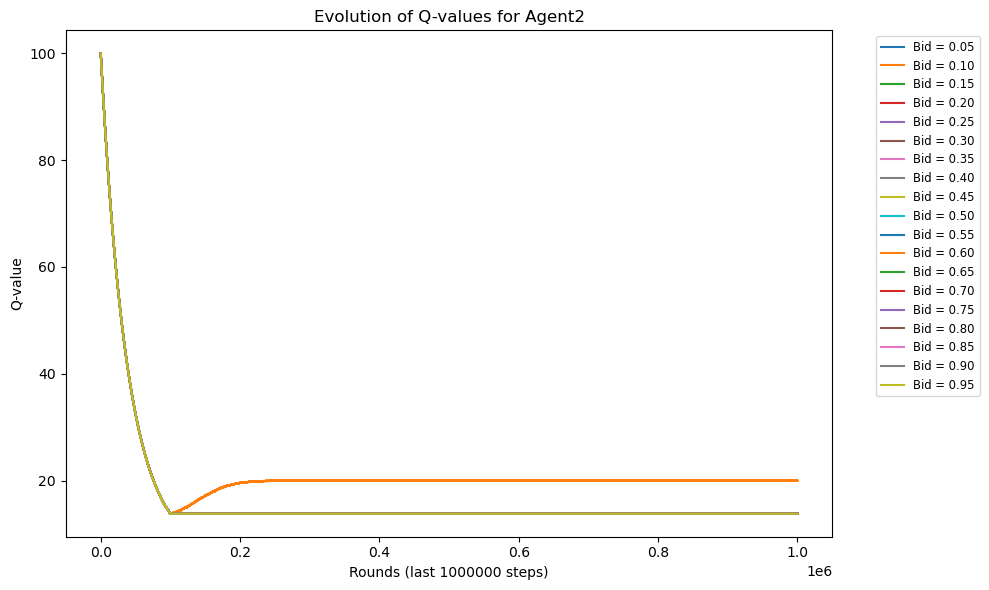

In [53]:
plot_q_evolution(SPA_history_01, "Agent2", 1000000)

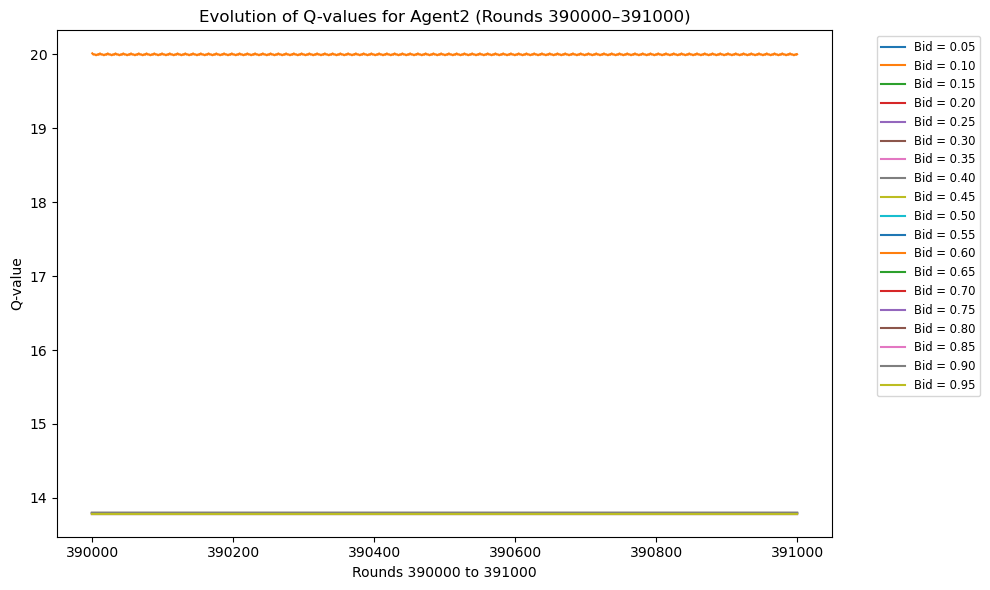

In [52]:
def plot_q_evolution_range(history, bidder_name, start_round, end_round):
    """
    Plot Q-value trajectories for all bids of `bidder_name` between
    start_round and end_round (inclusive).
    
    Parameters
    ----------
    history : list
        Auction history, where each element ends with q_snapshot: {bidder_name: q_values}.
    bidder_name : str
        Name of the bidder to plot.
    start_round : int
        Index of the starting round (0-based).
    end_round : int
        Index of the ending round (0-based, inclusive).
    """
    n = len(history)
    if n == 0:
        raise ValueError("History is empty.")
    if start_round < 0 or end_round >= n:
        raise ValueError(f"start_round and end_round must be within [0, {n-1}].")
    if end_round < start_round:
        raise ValueError("end_round must be greater than or equal to start_round.")

    # Slice history for the given range
    hist_slice = history[start_round:end_round+1]

    # Bid grid (same as in your environment)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot trajectories
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_slice, bidder_name, bid_idx)
        plt.plot(range(start_round, end_round+1), q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds {start_round} to {end_round}")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name} (Rounds {start_round}–{end_round})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

plot_q_evolution_range(SPA_history_01, "Agent2", 390000, 391000)